In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools
from numba import jit
from numba import njit
import time

In [2]:
N = 3

# lista = np.array([random.choice([-1, 1]) for n in range(N**2)])
lista = np.array([n+1 for n in range(N**2)])
matriz = lista.reshape(N,N)
matriz

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [3]:
# matriz[N-1,N-1], matriz[N-1].flatten(), matriz[N-1,0]
matriz[N-1][1:]

array([8, 9])

In [4]:
@jit
def matriz_aumentada(m):
    N = len(m)
    temp_list = np.zeros((N+2, N+2)); 
    
    temp_list[0][0] = m[N-1,N-1]
    temp_list[0][1:N+1] = m[N-1]
    temp_list[0][N+1] = m[N-1,0]
    for i in range(N):
        temp_list[i+1][0] = m[i,N-1]
        temp_list[i+1][1:N+1] = m[i]
        temp_list[i+1][N+1] = m[i,0]
        
    temp_list[N+1][0] = m[0,N-1]
    temp_list[N+1][1:N+1] = m[0]
    temp_list[N+1][N+1] = m[0,0]
    return temp_list

start = time.time()        
matriz_aumentada(matriz)
print(time.time()-start)

start = time.time()        
matriz_aumentada(matriz)
print(time.time()-start)


3.8182175159454346
0.0


### Filtros

In [5]:
filtro1 = np.matrix([[0, 1, 0],
                    [1, 0, 1],
                    [0, 1, 0]])

filtro2 = np.matrix([[1/np.sqrt(2)**3, 1, 1/np.sqrt(2)**3],
                    [1, 0, 1],
                    [1/np.sqrt(2)**3, 1, 1/np.sqrt(2)**3]])


@jit
def primeros_vecinos(m, i, j, filtro=filtro1):
    M_a = matriz_aumentada(m) 
    A = (M_a[i-1:i+2, j-1:j+2])
    return np.multiply(A,filtro)

primeros_vecinos(matriz, 1, 1), primeros_vecinos(matriz, 1, 1, filtro=filtro2)

(array([[0., 7., 0.],
        [3., 0., 2.],
        [0., 4., 0.]]),
 array([[3.18198052, 7.        , 2.82842712],
        [3.        , 0.        , 2.        ],
        [2.12132034, 4.        , 1.76776695]]))

In [6]:
start = time.time()        
primeros_vecinos(matriz, 2, 1), primeros_vecinos(matriz, 2, 1, filtro=filtro2)
print(time.time()-start)

0.0


In [7]:
J = 0.5;
@jit
def energia(m, i, j, filtro=filtro1):
    vecinos = primeros_vecinos(m, i, j, filtro=filtro)
    E = vecinos * m[i-1,j-1]
    return -J * np.sum(E)
  
energia(matriz, 1, 1), energia(matriz, 1, 1, filtro=filtro2)

(-8.0, -12.949747468305832)

In [8]:
start = time.time()       
energia(matriz, 1, 1), energia(matriz, 1, 1, filtro=filtro2)
print(time.time()-start)

0.0


### Prueba de energía

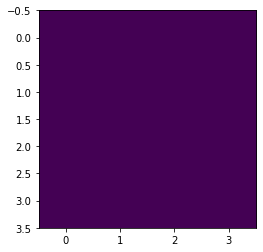

In [9]:
n1 = 4

# lista = np.array([random.choice([-1, 1]) for n in range(n1**2)])
lista = np.array([1 for n in range(n1**2)])
red = lista.reshape(n1,n1)
# Lista de índices

plt.imshow(red); plt.show()

In [10]:
z= 10
z%5, z//5 

(0, 2)

In [11]:
@jit
def energia_total(m, filtro=filtro1):
    s = 0; N = len(m)
    for i in np.arange(N**2):
        s += energia(m, i%N +1, i//N +1, filtro=filtro)
    return s
        
energia_total(red), energia_total(red, filtro=filtro2)

(-32.0, -43.313708498984745)

In [12]:
start = time.time()       
energia_total(red), energia_total(red, filtro=filtro2)
print(time.time()-start)

0.0010001659393310547


In [13]:
@jit
def energia_p(m, filtro=filtro1):
    return energia_total(m, filtro=filtro1)/len(m)**2
        
energia_p(red), energia_p(red, filtro=filtro2)

(-2.0, -2.0)

### Magnetización promedio

In [14]:
@jit
def mag_p(m):
    return np.sum(m)/len(m)**2

mag_p(red)

1.0

### Metropolis-Montecarlo

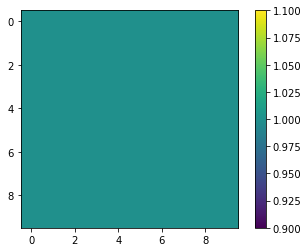

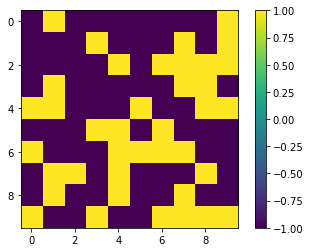

In [15]:
n1 = 10
lista = np.array([1 for n in range(n1**2)])
arriba = lista.reshape(n1,n1)

lista = np.array([random.choice([-1, 1]) for n in range(n1**2)])
red_a = lista.reshape(n1,n1)

lista = np.array([-1 for n in range(n1**2)])
abajo = lista.reshape(n1,n1)

plt.imshow(arriba); plt.colorbar(); plt.show()
plt.imshow(red_a); plt.colorbar()

In [16]:
@jit
def cambiar_spin(m, K=1, filtro=filtro1):
    N = len(m); e = 0
    m2 = np.copy(m)
    for k in np.arange(K):
        i,j = np.random.randint(N), np.random.randint(N)
        e += - 4 * energia(m2, i+1, j+1, filtro=filtro)
        m2[i,j] *= -1
    return m2, e

cambiar_spin(red, K=1, filtro=filtro2)

(array([[ 1,  1,  1,  1],
        [ 1,  1,  1, -1],
        [ 1,  1,  1,  1],
        [ 1,  1,  1,  1]]),
 10.82842712474619)

In [17]:
start = time.time()       
cambiar_spin(red, K=1, filtro=filtro2)
print(time.time()-start)

0.0009987354278564453


$$\beta = \frac{1}{k_B T}$$

In [19]:
K_B = 1;

@jit
def aceptar_cambio(m, T, K=1, filtro=filtro1):
    temp = cambiar_spin(m, K=K, filtro=filtro)
    
    t0 = np.exp(-temp[1]/(K_B*T))
    t1 = np.random.uniform(0,1)
    if (temp[1]<0) or (t0 > t1):
        m = temp[0] 
    return m

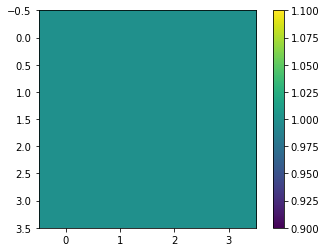

In [20]:
p = aceptar_cambio(red, 1.5, K=1, filtro=filtro1)
plt.imshow(p); plt.colorbar(); plt.show()

In [21]:
@jit
def evolucion(m, T, vueltas, K=1, filtro=filtro1):
    N = len(m)
    config = np.zeros((vueltas,N,N))
    for i in np.arange(vueltas):
        config[i] = m
        m = aceptar_cambio(m, T, K=1, filtro=filtro)
    return config

In [22]:
@jit
def observables(config, filtro=filtro1):
    N = len(config)
    energias, mag = np.zeros(N), np.zeros(N)
    for i in np.arange(N):
        energias[i] = energia_p(config[i], filtro=filtro)
        mag[i] = mag_p(config[i])
    return energias, mag

In [23]:
config1 = evolucion(arriba, 3, 20000, filtro=filtro1)
config2 = evolucion(abajo,  3, 20000, filtro=filtro1)
config_a= evolucion(red_a,  3, 20000, filtro=filtro1)

In [24]:
energias1, mag1 = observables(config1, filtro=filtro1)
energias2, mag2 = observables(config2, filtro=filtro1)
energias_a, mag_a = observables(config_a, filtro=filtro1)

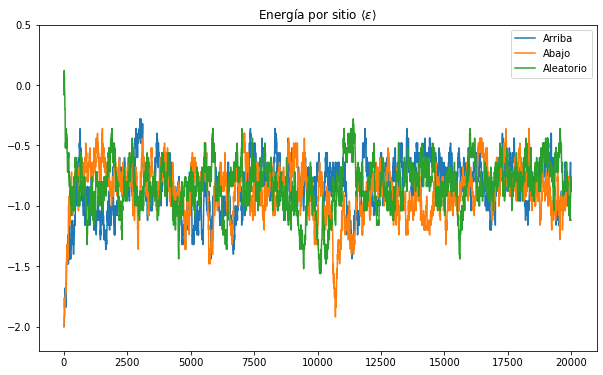

In [25]:
plt.figure(figsize=(10,6))
plt.plot(range(len(energias1)), energias1, label="Arriba")
plt.plot(range(len(energias2)), energias2, label="Abajo")
plt.plot(range(len(energias_a)), energias_a,label="Aleatorio")
plt.ylim(bottom=-2.2, top=0.5); plt.legend();
plt.title(r"Energía por sitio $\langle \varepsilon\rangle$")
plt.show()

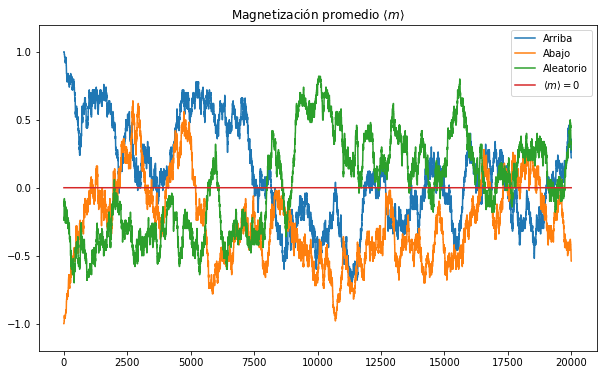

In [26]:
plt.figure(figsize=(10,6))
plt.plot(range(len(energias1)), mag1, label="Arriba")
plt.plot(range(len(energias2)), mag2, label="Abajo")
plt.plot(range(len(energias_a)), mag_a,label="Aleatorio")
plt.plot(range(len(energias_a)), mag_a*0,label=r"$\langle m\rangle=0$")
plt.ylim(bottom=-1.2, top=1.2); plt.legend();
plt.title(r"Magnetización promedio $\langle m\rangle$")
plt.show()

### Método de Newton-Rapson

In [27]:
def newton(f,df,a,b,epsilon):
    dx=2*epsilon
    contador = 0
    x=0.5*(a+b)
    while dx> epsilon and contador<1000:
        x1=x-f(x)/df(x)
        dx=abs(x-x1)
        x=x1
        contador=contador+1
    return [x,contador]

\begin{equation}\label{eq:1}
    2\tanh^2\left(\frac{2J}{K_BT_c}\right)=1
\end{equation}


Entonces proponemos la función $f(T)$ tal que
\begin{equation}
f(T)=2\tanh^2\left(\frac{2J}{K_BT}\right)-1
\end{equation}

\begin{equation}
\Rightarrow \frac{df(T)}{dT}=\frac{d}{dT}\left(2\tanh^2\left(\frac{2J}{K_BT}\right)-1\right)=-\frac{8J}{T^2K_B}\tanh \left(\frac{2 J}{K_B T}\right)   \text{sech}^2\left(\frac{2 J}{K_B T}\right)
\end{equation}

In [28]:
J = 0.5; K_B=1;
def f(T):
    return 2*(np.tanh(2*J/(K_B*T)))**2-1

def df(T):
    t1 = -8/((T**2)*K_B)
    t2 = np.tanh(2*J/(K_B*T))
    t3 = 1/(np.cosh(2*J/(K_B*T))**2)       
    return t1*t2*t3

Tc = newton(f,df,1,1.5,1e-5)[0]
Tc

1.134598744438543

$$T_c=1.134598744438543$$

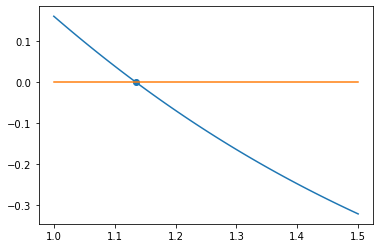

In [29]:
T = np.linspace(1,1.5);
plt.plot(T,f(T))
plt.plot(T,np.zeros(50))
plt.scatter(Tc,f(Tc))
plt.show()